In [1]:
""" Problem 8.1.2 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, log10, sqrt

C:\Users\Gabriel\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


([<matplotlib.axis.XTick at 0x1fd35847770>,
 [Text(0.1, 0, '$\\mathdefault{10^{-1}}$'),
  Text(0.8, 0, ''),
  Text(1.0, 0, '$\\mathdefault{10^{0}}$'),
  Text(2.0, 0, ''),
  Text(10.0, 0, '$\\mathdefault{10^{1}}$')])

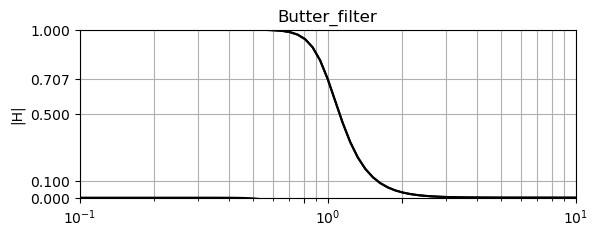

In [2]:
phi3 = 36*(pi/180)
phi4 = 72*(pi/180)
n5 = [0,0,0,0,0,1]
dc = [1,2*cos(phi3),1]
dd = [1,2*cos(phi4),1]
de = np.convolve(dc, dd)
df = [1,1]
d5 = np.convolve(de, df)

num = n5
den = d5

system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system)

plt.subplot(211)
plt.semilogx(w,10**(0.05*Hmag),'k') # Plot amplitude, not dB.
plt.plot(w,10**(0.05*Hmag),'k')
plt.semilogx(w,Hmag,'k') #
plt.title('Butter_filter')
plt.axis([0.1, 10, 0, 1])
plt.yticks([0, 0.1, .5, .707, 1])
plt.xticks([.5,1,5])
plt.grid(which='both')
plt.ylabel('|H|')
plt.xticks([.1,.8,1,2,10])

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_15480\1007006903.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[m] = C.dot(x) + D*f[m]


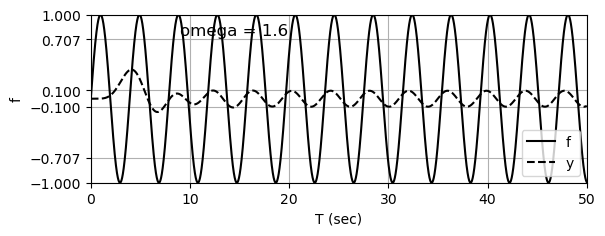

In [21]:
dt = 0.001
NN = 50000
TT = np.arange(0,NN*dt,dt)
y = np.zeros(NN)
f = np.zeros(NN)

A,B,C,D = sig.tf2ss(num,den)
x = np.zeros(np.shape(B))

""" The sinusodal input """
omega = 1.6
for n in range(NN):
    f[n] = sin(omega*n*dt)

for m in range(NN):
    x = x + dt*A.dot(x) + dt*B*f[m]
    y[m] = C.dot(x) + D*f[m]

plt.subplot(211)
plt.plot(TT,f,'k', label='f')
plt.axis([0, NN*dt,-1,1])
plt.grid()
plt.ylabel('f')

plt.plot(TT,y,'k--', label='y')
plt.yticks([-1, -.707, -.1, .1,.707, 1 ])
plt.text(9,.75,'omega = {}'.format(round(omega,1)),fontsize=12)
plt.xlabel('T (sec)')
plt.legend()
plt.show()